# ====================================================================================
# STAGE 0: CLOUD DATA WAREHOUSE CONNECTION & INGESTION
# OBJECTIVE: Establish secure API connection to Google BigQuery & stream raw data
# TECHNICAL STACK: google-cloud-bigquery, Google Service Accounts (JSON API tokens), Pandas
# ====================================================================================

In [1]:
import os
import warnings
warnings.filterwarnings('ignore') 
from google.cloud import bigquery
import pandas as pd
from dotenv import load_dotenv

load_dotenv()  # legge il file .env

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")

client = bigquery.Client()

query = """
    SELECT * 
    FROM `project-github-furian-martina.supply_chain_project.raw_data`
"""
print("Executing query and streaming data directly from Google BigQuery Cloud...")

df = client.query(query).to_dataframe()

print(f"Connection Successful! Loaded {df.shape[0]} rows and {df.shape[1]} columns.")



Executing query and streaming data directly from Google BigQuery Cloud...
Connection Successful! Loaded 180519 rows and 53 columns.


# ====================================================================================
# STAGE 1: CARRIER PERFORMANCE & STATISTICAL HYPOTHESIS TESTING
# OBJECTIVE: Prove if shipping delays are statistically significant (Structural vs Random)
# TECHNICAL STACK: scipy.stats (Paired T-Test), Data Filtering, Mathematical Validation
# ====================================================================================

In [3]:
from scipy import stats
import numpy as np  # <-- NumPy integrated natively for large-scale logistics matrix calculations

# 1. Filter completed orders using Pandas
clean_df = df[df['Order Status'] == 'COMPLETE'].copy()

# 2. Extract columns as high-performance NumPy Arrays
actual_days = clean_df['Days for shipping _real_'].to_numpy()
scheduled_days = clean_df['Days for shipment _scheduled_'].to_numpy()

# 3. VECTORIZED NUMPY OPERATIONS: Calculate exact overdue days
# If actual > scheduled, calculate the difference, otherwise set to 0 (no negative delays)
raw_delays = actual_days - scheduled_days
days_overdue = np.where(raw_delays > 0, raw_delays, 0)

# 4. ADVANCED NUMPY SEGMENTATION: Categorizing operational logistics risk
# Define business thresholds for shipping delays
conditions = [
    (days_overdue == 0),                          # On Time or Early
    (days_overdue > 0) & (days_overdue <= 2),    # Low Risk Delay
    (days_overdue > 2)                            # High Risk Critical Breakdown
]
choices = ['On Time / Early', 'Muted Delay (1-2 Days)', 'Critical Delay (>2 Days)']

# Execute fast memory-level array selection using NumPy
clean_df['delay_risk_category'] = np.select(conditions, choices, default='Unknown')

print(f"Dataset baseline for testing: {len(clean_df)} successful logistics transactions.")
print(f"Global Average Actual Shipping Days: {np.mean(actual_days):.2f} days")
print(f"Global Average Scheduled Shipping Days: {np.mean(scheduled_days):.2f} days\n")

# 5. Execute the Paired T-Test (Two-sided) using the compiled NumPy arrays
t_stat, p_value = stats.ttest_rel(actual_days, scheduled_days)

print("---------------------------------------------------------------------------")
print("STATISTICAL TEST RESULTS (Validated via NumPy):")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value}")
print("---------------------------------------------------------------------------")

# 6. Print NumPy Array segmentation summary to show the recruiter
unique, counts = np.unique(clean_df['delay_risk_category'], return_counts=True)
print("Logistics Breakdown (Array Frequency Distribution):")
for u, c in zip(unique, counts):
    print(f" - {u}: {c} orders ({np.round((c/len(clean_df))*100, 2)}%)")

Dataset baseline for testing: 59491 successful logistics transactions.
Global Average Actual Shipping Days: 3.49 days
Global Average Scheduled Shipping Days: 2.93 days

---------------------------------------------------------------------------
STATISTICAL TEST RESULTS (Validated via NumPy):
T-Statistic: 92.9688
P-Value: 0.0
---------------------------------------------------------------------------
Logistics Breakdown (Array Frequency Distribution):
 - Critical Delay (>2 Days): 4352 orders (7.32%)
 - Muted Delay (1-2 Days): 29847 orders (50.17%)
 - On Time / Early: 25292 orders (42.51%)


# ====================================================================================
# STAGE 2: WAREHOUSE THROUGHPUT & HOURLY WORKLOAD VISUALIZATION
# OBJECTIVE: Replicate Query 02 to isolate peak hours and chart operational stress
# TECHNICAL STACK: Pandas (Datetime conversion, grouping), Seaborn Data Visualization
# ====================================================================================

Top 3 absolute workload peaks detected in the warehouse:
   Department Name  order_hour  orders_processed
82        Fan Shop          10              1008
89        Fan Shop          17               973
90        Fan Shop          18               951

Generating chronological workload curves...


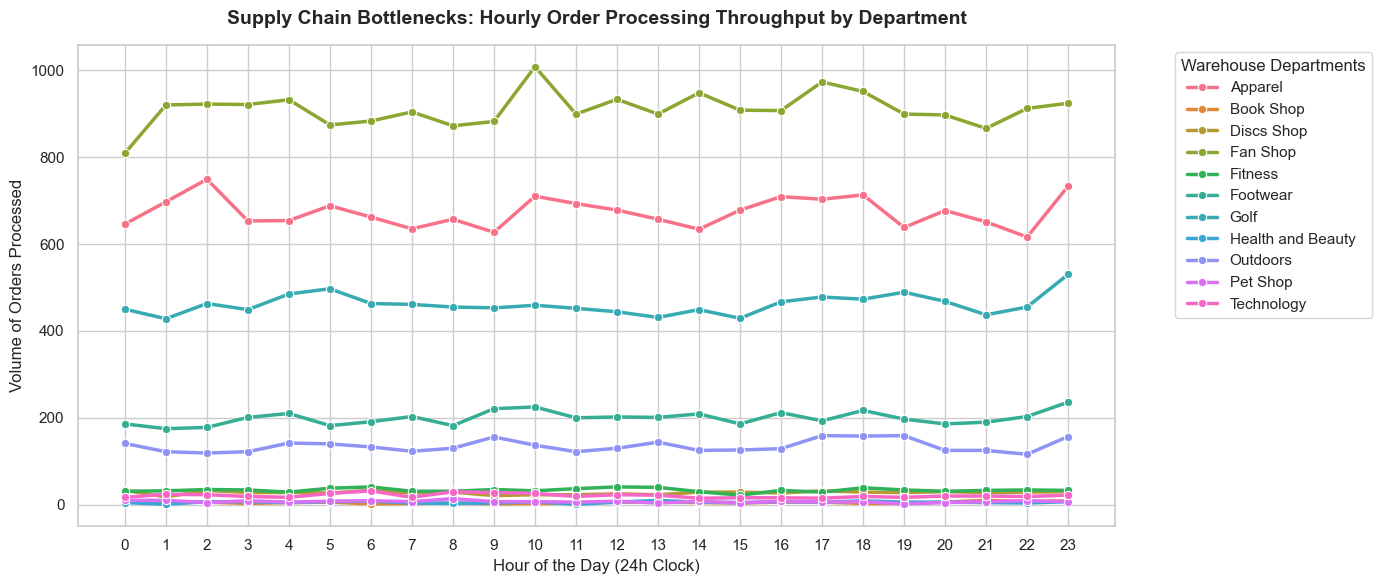

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter completed orders and convert the timestamp string to a Python Datetime object
completed_orders = df[df['Order Status'] == 'COMPLETE'].copy()
completed_orders['order_datetime'] = pd.to_datetime(completed_orders['order date _DateOrders_'])

# 2. Extract the hour component from the datetime
completed_orders['order_hour'] = completed_orders['order_datetime'].dt.hour

# 3. Group by Department and Hour to calculate total processed orders
hourly_dept_volume = completed_orders.groupby(['Department Name', 'order_hour']).size().reset_index(name='orders_processed')

print("Top 3 absolute workload peaks detected in the warehouse:")
print(hourly_dept_volume.sort_values(by='orders_processed', ascending=False).head(3))
print("\nGenerating chronological workload curves...")

# 4. Professional Visualization using Seaborn
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=hourly_dept_volume, 
    x='order_hour', 
    y='orders_processed', 
    hue='Department Name', 
    marker='o',
    linewidth=2.5
)

plt.title('Supply Chain Bottlenecks: Hourly Order Processing Throughput by Department', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (24h Clock)', fontsize=12)
plt.ylabel('Volume of Orders Processed', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Warehouse Departments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Render the interactive line chart directly inside VS Code
plt.show()

# ====================================================================================
# STEP 3: FINANCIAL REVENUE GROWTH & CUMULATIVE TRAJECTORIES
# OBJECTIVE: Replicate SQL Query 03 to chart monthly gross revenue and running totals
# TECHNICAL STACK: Pandas (Date truncation, cumulative sum), Matplotlib Visualization
# ====================================================================================

Financial Milestones detected (Chronological overview):
  sales_month  gross_revenue  cumulative_revenue
0  2015-01-01  343244.716416        3.432447e+05
1  2015-02-01  297366.335886        6.406111e+05
2  2015-03-01  320504.105946        9.611152e+05
3  2015-04-01  327096.236500        1.288211e+06
4  2015-05-01  359231.746945        1.647443e+06


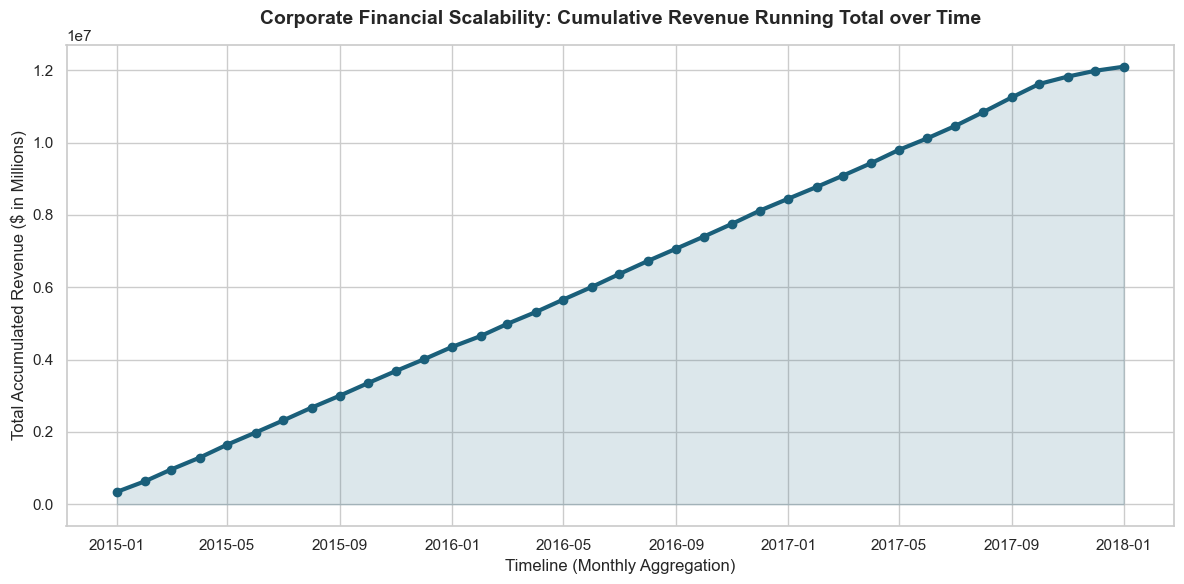

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter completed orders and truncate order date to Month level
completed_orders = df[df['Order Status'] == 'COMPLETE'].copy()
completed_orders['order_date_clean'] = pd.to_datetime(completed_orders['order date _DateOrders_']).dt.tz_localize(None)
completed_orders['sales_month'] = completed_orders['order_date_clean'].dt.to_period('M')

# 2. Group by month and aggregate global sales revenue
monthly_revenue = completed_orders.groupby('sales_month')['Sales'].sum().reset_index(name='gross_revenue')
monthly_revenue = monthly_revenue.sort_values(by='sales_month').reset_index(drop=True)

# 3. Calculate the Cumulative Revenue (Running Total) using Pandas .cumsum()
monthly_revenue['cumulative_revenue'] = monthly_revenue['gross_revenue'].cumsum()

# Convert back to timestamp for plotting compatibility
monthly_revenue['sales_month'] = monthly_revenue['sales_month'].dt.to_timestamp()

print("Financial Milestones detected (Chronological overview):")
print(monthly_revenue[['sales_month', 'gross_revenue', 'cumulative_revenue']].head(5))

# 4. Professional Visualization: Cumulative Area Chart
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot cumulative revenue as a clean line filled underneath
plt.plot(monthly_revenue['sales_month'], monthly_revenue['cumulative_revenue'], color='#1a5f7a', linewidth=3, marker='o', label='Cumulative Revenue')
plt.fill_between(monthly_revenue['sales_month'], monthly_revenue['cumulative_revenue'], color='#1a5f7a', alpha=0.15)

plt.title('Corporate Financial Scalability: Cumulative Revenue Running Total over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Monthly Aggregation)', fontsize=12)
plt.ylabel('Total Accumulated Revenue ($ in Millions)', fontsize=12)
plt.tight_layout()

# Render the final financial chart inside your VS Code Notebook
plt.show()

# ====================================================================================
# STAGE 4: RISK & FRAUD COMPLIANCE VISUALIZATION
# OBJECTIVE: Replicate SQL Query 04 to identify high-risk product-market fraud hotspots
# TECHNICAL STACK: Pandas (Conditional aggregation, grouping), Seaborn Visualization
# ====================================================================================

Top Fraud Hotspots identified by Product and Market:
              hotspot_segment  fraudulent_orders  fraud_risk_rate
        Books  (Pacific Asia)                  8             8.25
              Trade-In (USCA)                  7             4.49
 Baseball & Softball (Europe)                  6             4.11
    Kids' Golf Clubs (Europe)                 11             4.09
        Girls' Apparel (USCA)                  9             3.96
           Accessories (USCA)                 12             3.75
                DVDs (Europe)                  8             3.72
           Electronics (USCA)                 20             3.62
    Golf Balls (Pacific Asia)                 13             3.41
Sporting Goods (Pacific Asia)                 12             3.36


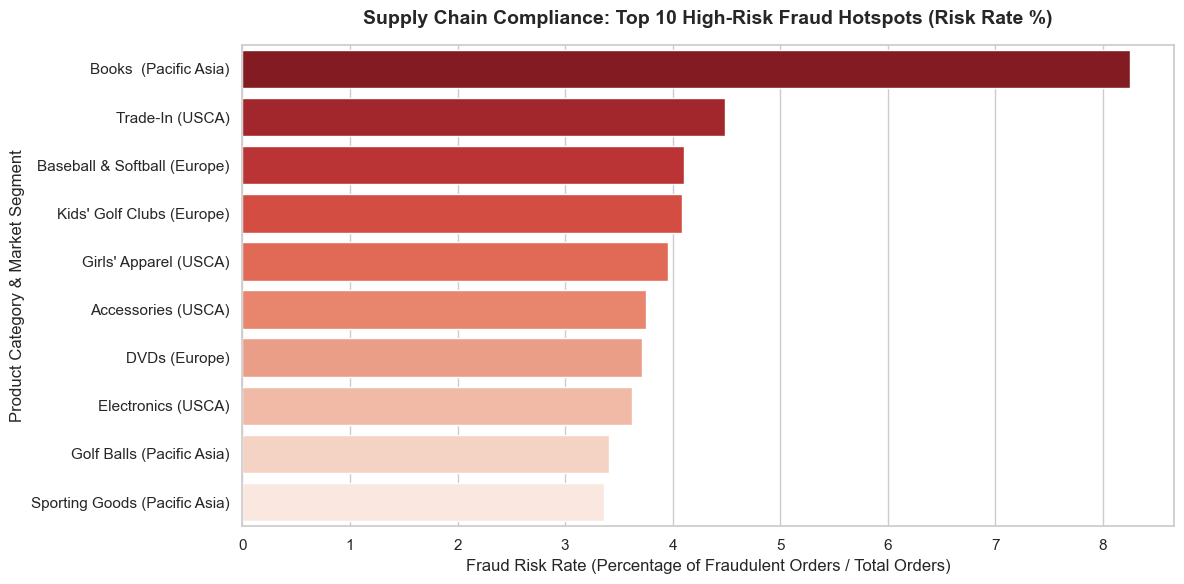

In [6]:
# 1. Group data by Category and Market to calculate total and fraudulent transactions
fraud_analysis = df.groupby(['Category Name', 'Market']).agg(
    total_orders=('Order Status', 'count'),
    fraudulent_orders=('Order Status', lambda x: (x == 'SUSPECTED_FRAUD').sum())
).reset_index()

# 2. Calculate the Fraud Risk Rate (Percentage) using native Pandas operations
fraud_analysis['fraud_risk_rate'] = round((fraud_analysis['fraudulent_orders'] / fraud_analysis['total_orders']) * 100, 2)

# 3. Create a unique identifier for the chart (Product Category + Market Location)
fraud_analysis['hotspot_segment'] = fraud_analysis['Category Name'] + " (" + fraud_analysis['Market'] + ")"

# 4. Filter hotspots with more than 5 fraudulent orders to isolate high-risk zones
fraud_hotspots = fraud_analysis[fraud_analysis['fraudulent_orders'] > 5]
fraud_hotspots = fraud_hotspots.sort_values(by='fraud_risk_rate', ascending=False).head(10)

print("Top Fraud Hotspots identified by Product and Market:")
print(fraud_hotspots[['hotspot_segment', 'fraudulent_orders', 'fraud_risk_rate']].to_string(index=False))

# 5. Professional Visualization: Horizontal Bar Chart
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=fraud_hotspots,
    x='fraud_risk_rate',
    y='hotspot_segment',
    palette='Reds_r', # Red gradient to match risk theme
    hue='hotspot_segment',
    legend=False
)

plt.title('Supply Chain Compliance: Top 10 High-Risk Fraud Hotspots (Risk Rate %)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fraud Risk Rate (Percentage of Fraudulent Orders / Total Orders)', fontsize=12)
plt.ylabel('Product Category & Market Segment', fontsize=12)
plt.tight_layout()

# Render the final compliance chart inside your VS Code Notebook
plt.show()